In [34]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings("ignore")

import csv data as pandas df

In [35]:
df = pd.read_csv("data/raw.csv")

In [36]:
df.head()

,gender,race/ethnicity,parental level of education,lunch,test preparation course,math score,reading score,writing score
0,female,group B,bachelor's degree,standard,none,72,72,74
1,female,group C,some college,standard,completed,69,90,88
2,female,group B,master's degree,standard,none,90,95,93
3,male,group A,associate's degree,free/reduced,none,47,57,44
4,male,group C,some college,standard,none,76,78,75


1. Check overall info about the data

In [37]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 8 columns):
 #   Column                       Non-Null Count  Dtype 
---  ------                       --------------  ----- 
 0   gender                       1000 non-null   object
 1   race/ethnicity               1000 non-null   object
 2   parental level of education  1000 non-null   object
 3   lunch                        1000 non-null   object
 4   test preparation course      1000 non-null   object
 5   math score                   1000 non-null   int64 
 6   reading score                1000 non-null   int64 
 7   writing score                1000 non-null   int64 
dtypes: int64(3), object(5)
memory usage: 62.6+ KB


In [38]:
df.shape

(1000, 8)

2. Check missing values (there are no missing  values)

In [39]:
df.isna().sum()

gender                         0
race/ethnicity                 0
parental level of education    0
lunch                          0
test preparation course        0
math score                     0
reading score                  0
writing score                  0
dtype: int64

There are no missing values in the data set

3. Check duplicates (there are no duplicate values in the data set)

In [40]:
df.duplicated().sum()

0

4. Check unique values

In [41]:
df.nunique()

gender                          2
race/ethnicity                  5
parental level of education     6
lunch                           2
test preparation course         2
math score                     81
reading score                  72
writing score                  77
dtype: int64

5. Check statistics of the dataset

In [42]:
df.describe()

,math score,reading score,writing score
count,1000.00000,1000.000000,1000.000000
mean,66.08900,69.169000,68.054000
std,15.16308,14.600192,15.195657
min,0.00000,17.000000,10.000000
25%,57.00000,59.000000,57.750000
50%,66.00000,70.000000,69.000000
75%,77.00000,79.000000,79.000000
max,100.00000,100.000000,100.000000


In [43]:
print("Categories in 'gender' column: ", end=" ")
print(df['gender'].unique())

print("Categories in 'race/ethnicity' column: ", end=" ")
print(df['race/ethnicity'].unique())

print("Categories in 'parental level of education' column: ", end=" ")
print(df['parental level of education'].unique())

print("Categories in 'lunch' column: ", end=" ")
print(df['lunch'].unique())

print("Categories in 'test preparation course' column: ", end=" ")
print(df['test preparation course'].unique())

Categories in 'gender' column:  ['female' 'male']
Categories in 'race/ethnicity' column:  ['group B' 'group C' 'group A' 'group D' 'group E']
Categories in 'parental level of education' column:  ["bachelor's degree" 'some college' "master's degree" "associate's degree"
 'high school' 'some high school']
Categories in 'lunch' column:  ['standard' 'free/reduced']
Categories in 'test preparation course' column:  ['none' 'completed']


In [44]:
#define numerical and categorical columns
numerical_cols = [features for features in df.columns if df[features].dtype != 'O']
categorical_cols = [features for features in df.columns if df[features].dtype == 'O']

print(f"we have {len(numerical_cols)} numerical columns : {numerical_cols} ")
print(f"we have {len(categorical_cols)} categorical columns : {categorical_cols} ")

we have 3 numerical columns : ['math score', 'reading score', 'writing score'] 
we have 5 categorical columns : ['gender', 'race/ethnicity', 'parental level of education', 'lunch', 'test preparation course'] 


In [45]:
df.head(2)

,gender,race/ethnicity,parental level of education,lunch,test preparation course,math score,reading score,writing score
0,female,group B,bachelor's degree,standard,none,72,72,74
1,female,group C,some college,standard,completed,69,90,88


In [46]:
#adding columns for total score and average score

df['total_score'] = df['math score'] + df['reading score'] + df['writing score']
df['average_score'] = df['total_score'] / 3
df.head()

,gender,race/ethnicity,parental level of education,lunch,test preparation course,math score,reading score,writing score,total_score,average_score
0,female,group B,bachelor's degree,standard,none,72,72,74,218,72.666667
1,female,group C,some college,standard,completed,69,90,88,247,82.333333
2,female,group B,master's degree,standard,none,90,95,93,278,92.666667
3,male,group A,associate's degree,free/reduced,none,47,57,44,148,49.333333
4,male,group C,some college,standard,none,76,78,75,229,76.333333


In [47]:
reading_full = df[df['reading score'] == 100]['average_score'].count()
writing_full = df[df['writing score'] == 100]['average_score'].count()
math_full = df[df['math score'] == 100]['average_score'].count()

print(f"Number of students with full score in reading: {reading_full}")
print(f"Number of students with full score in writing: {writing_full}")
print(f"Number of students with full score in math: {math_full}")   

Number of students with full score in reading: 17
Number of students with full score in writing: 14
Number of students with full score in math: 7


In [48]:
reading_less_20 = df[df['reading score'] <= 20]['average_score'].count()
writing_less_20 = df[df['writing score'] <= 20]['average_score'].count()
math_less_20 = df[df['math score'] <= 20]['average_score'].count()

print(f"Number of students with score less than or equal to 20 in reading: {reading_less_20}")
print(f"Number of students with score less than or equal to 20 in writing: {writing_less_20}")
print(f"Number of students with score less than or equal to 20 in math: {math_less_20}")

Number of students with score less than or equal to 20 in reading: 1
Number of students with score less than or equal to 20 in writing: 3
Number of students with score less than or equal to 20 in math: 4


Insights

- from above data we can see that students have performed worse in Maths
- studnents performed therir best in reading section


# 4. Exploratory Data (visualisation)


- plotting histogram with average score distribution
- KDE for making conclusions from data

# Histogram & KDE

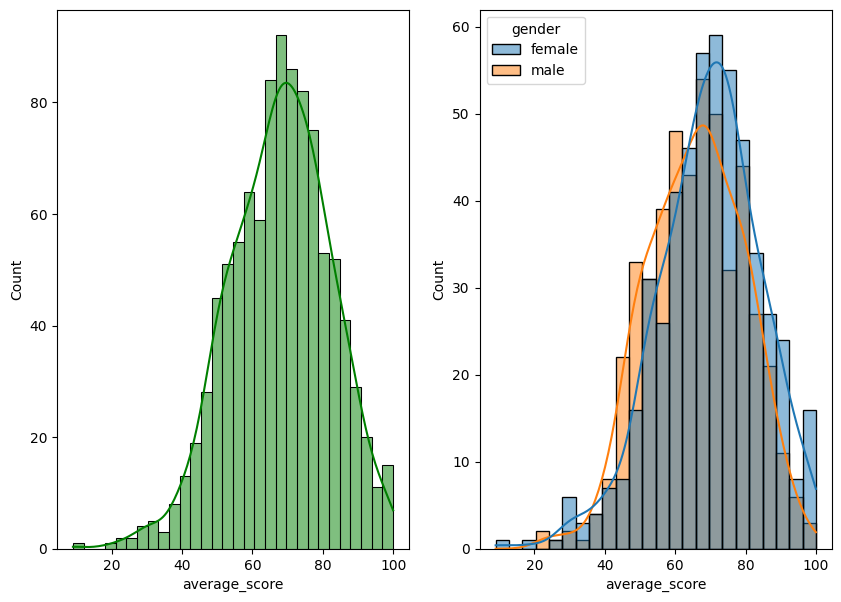

In [49]:
fig, axs = plt.subplots(1, 2, figsize=(10, 7))
plt.subplot(121)
sns.histplot(data=df,x='average_score',bins=30,kde=True,color='g')
plt.subplot(122)
sns.histplot(data=df,x='average_score',kde=True,hue='gender')
plt.show()


Insights 

Female students performed well than male students

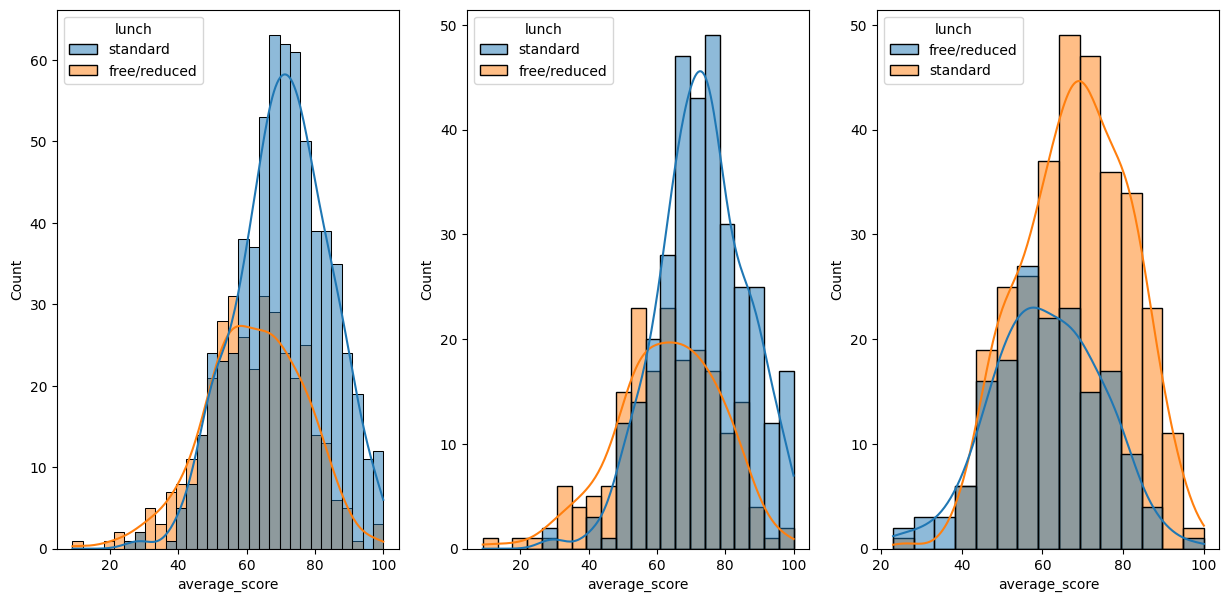

In [50]:
plt.subplots(1, 3, figsize=(15, 7))
plt.subplot(131)
sns.histplot(data=df,x='average_score',bins=30,kde=True,hue='lunch')
plt.subplot(132)
sns.histplot(data=df[df.gender=='female'],x='average_score',kde=True, hue='lunch')
plt.subplot(133)
sns.histplot(data=df[df.gender=='male'],x='average_score',kde=True, hue='lunch')
plt.show()


# Insights

- Standard lunch helps perform better in exams
- Standard lunch helps perform better in exams be it a male or a female student


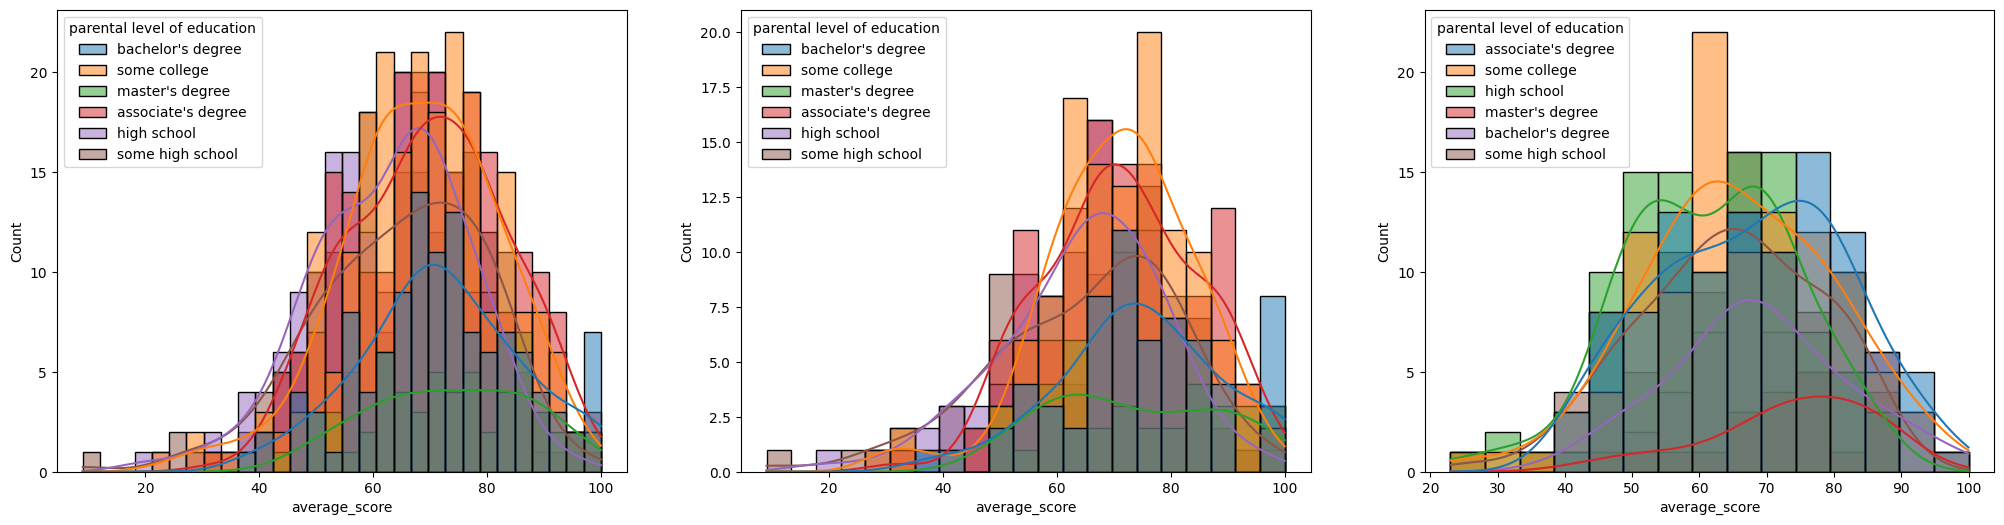

In [51]:
plt.subplots(1, 3, figsize=(25, 6))
plt.subplot(131)
sns.histplot(data=df,x='average_score',bins=30,kde=True,hue='parental level of education')



plt.subplot(132)
sns.histplot(data=df[df.gender=='female'],x='average_score',kde=True, hue='parental level of education')
plt.subplot(133)
sns.histplot(data=df[df.gender=='male'],x='average_score',kde=True, hue='parental level of education')
plt.show()

# Insights 

- overall we can conclude that there is no huge influence of paten's education level on students' performence in exam 
- in 2nd plot , we can see that students whose parents have some college or associate degree tend to perform better than others 
- 3rd plot suggests that there is no affects of parental education level on male students' performance on their exams 



Visualising data according to race/ethnicity 

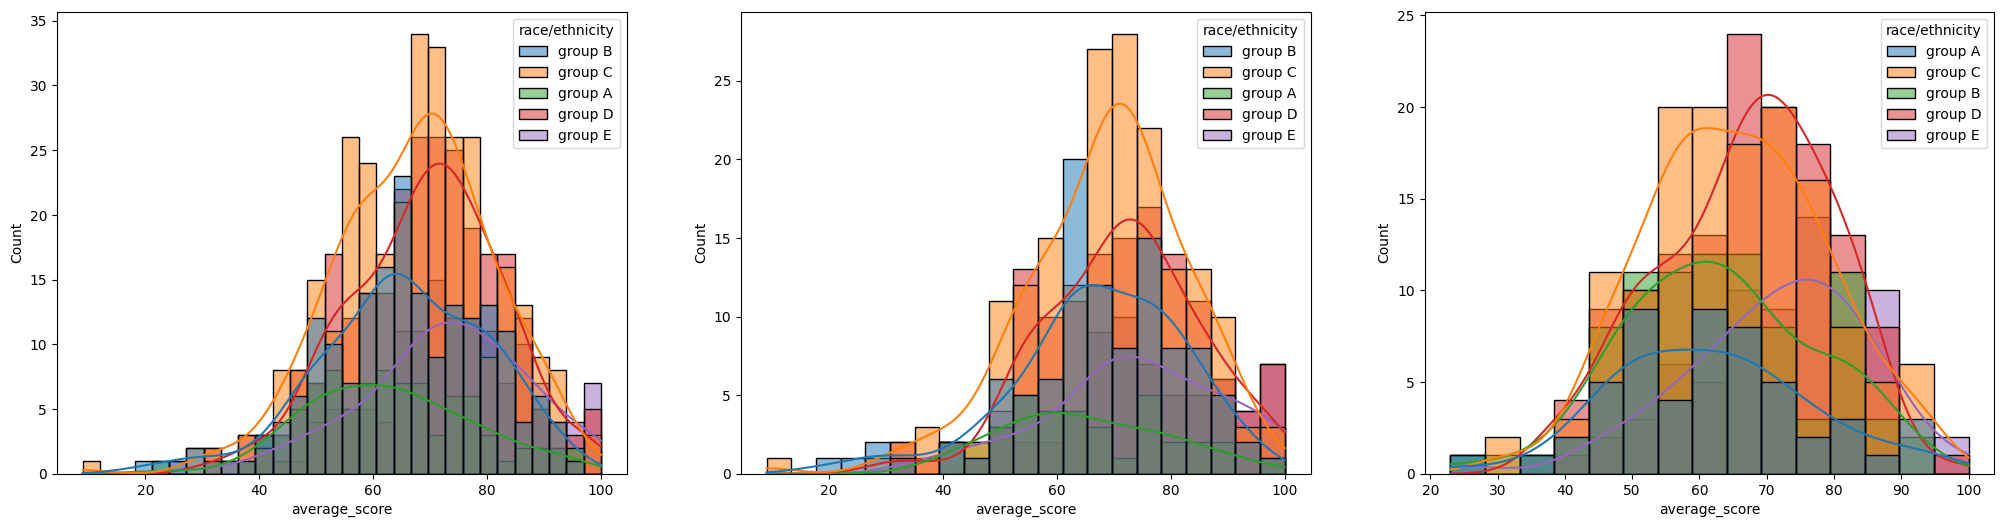

In [52]:
plt.subplots(1, 3, figsize=(25, 6))
plt.subplot(131)
sns.histplot(data=df,x='average_score',bins=30,kde=True,hue='race/ethnicity')
plt.subplot(132)
sns.histplot(data=df[df.gender=='female'],x='average_score',kde=True, hue='race/ethnicity')
plt.subplot(133)
sns.histplot(data=df[df.gender=='male'],x='average_score',kde=True, hue='race/ethnicity')
plt.show()

# Insights 
- for female students, overall group C students perform better than other groups of their race/ethinicity , and those belonging to group A perform worse
- for male students , group D  & C students outperform students from other groups
- overall, group A and B students(male and female ) performs poorly in exams 


Maximum scores of students in all three subjects 


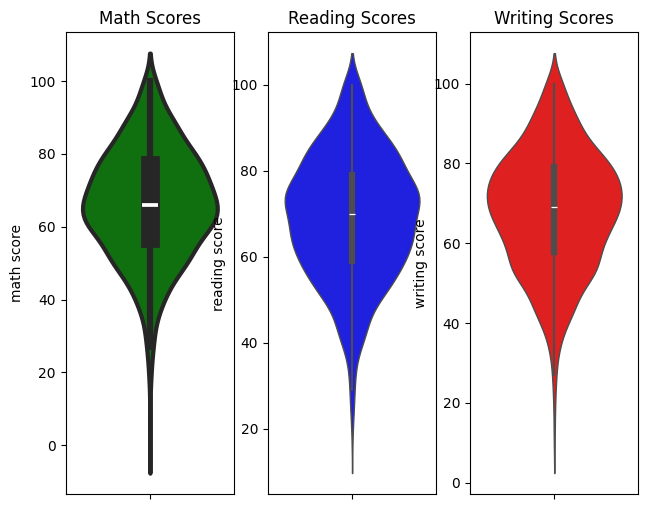

In [53]:
plt.figure(figsize=(10, 6))
plt.subplot(1, 4, 1)
plt.title("Math Scores")
sns.violinplot(y='math score', data=df, color='g', linewidth=3)
plt.subplot(1, 4, 2)
plt.title("Reading Scores")
sns.violinplot(y='reading score', data=df, color='b', linewidth=1)
plt.subplot(1, 4, 3)
plt.title("Writing Scores")
sns.violinplot(y='writing score', data=df, color='r', linewidth=1)
plt.show()


# Insights 

- from above plots we can colclude that most of the students scored 60-80 in Maths while in reading and writing most of them scored between 55-80.


Multivariate analysis using pieplot

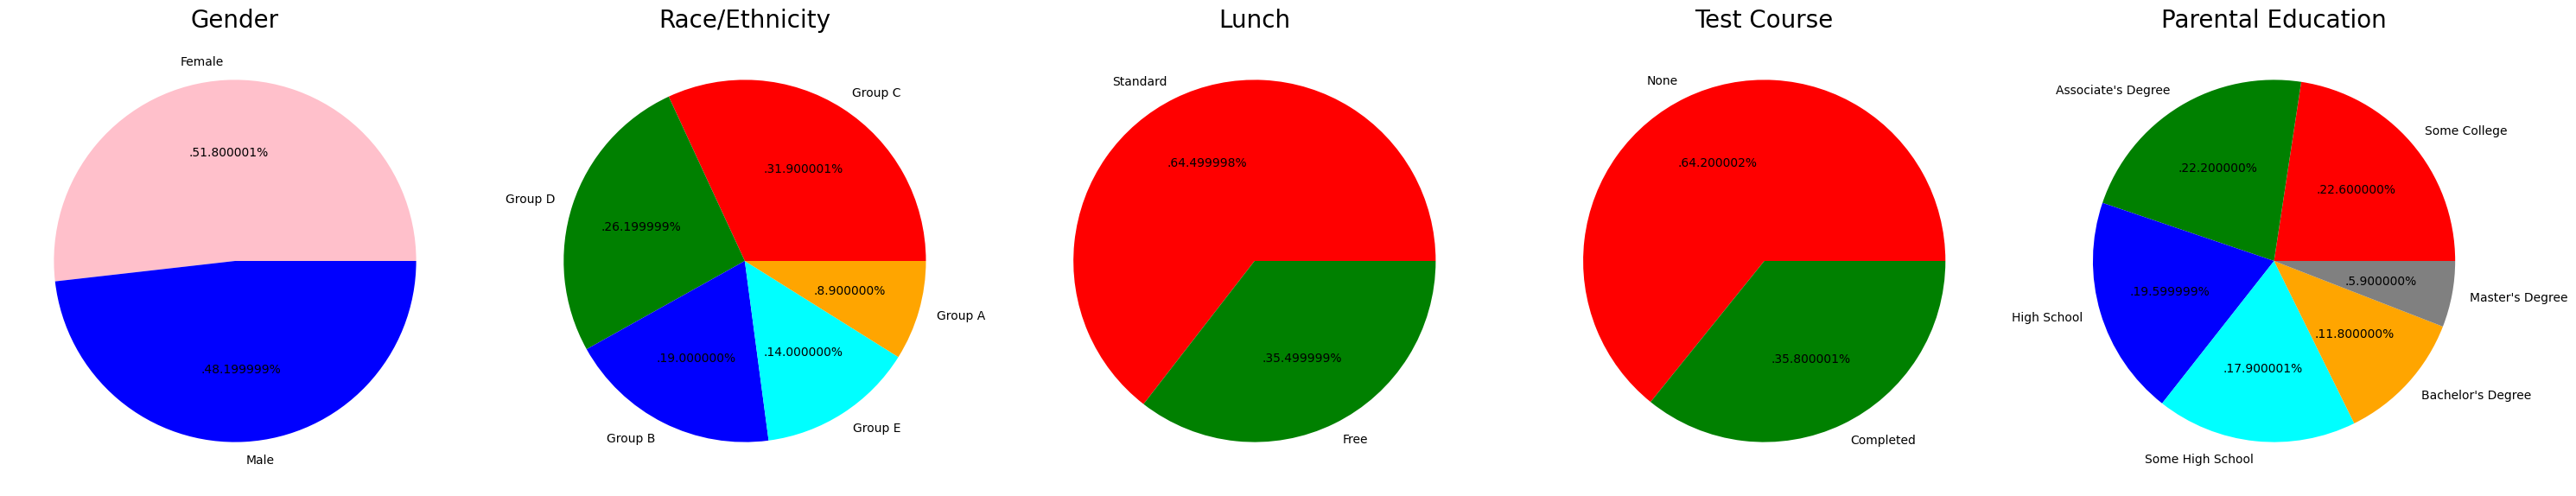

In [54]:
plt.rcParams['figure.figsize'] = (30, 12)

plt.subplot(1, 5, 1)
size = df['gender'].value_counts()
labels = 'Female', 'Male'
color = ['pink','blue']
plt.pie(size, colors = color, labels = labels,autopct = '.%2f%%')
plt.title('Gender', fontsize = 20)
plt.axis('off')



plt.subplot(1, 5, 2)
size = df['race/ethnicity'].value_counts()
labels = 'Group C', 'Group D','Group B','Group E','Group A'
color = ['red', 'green', 'blue', 'cyan','orange']
plt.pie(size, colors = color,labels = labels,autopct = '.%2f%%')
plt.title('Race/Ethnicity', fontsize = 20)
plt.axis('off')



plt.subplot(1, 5, 3)
size = df['lunch'].value_counts()
labels = 'Standard', 'Free'
color = ['red','green']
plt.pie(size, colors = color,labels = labels,autopct = '.%2f%%')
plt.title('Lunch', fontsize = 20)
plt.axis('off')


plt.subplot(1, 5, 4)
size = df['test preparation course'].value_counts()
labels = 'None', 'Completed'
color = ['red','green']
plt.pie(size, colors = color,labels = labels,autopct = '.%2f%%')
plt.title('Test Course', fontsize = 20)
plt.axis('off')


plt.subplot(1, 5, 5)
size = df['parental level of education'].value_counts()
labels = 'Some College', "Associate's Degree",'High School','Some High School',"Bachelor's Degree","Master's Degree"
color = ['red', 'green', 'blue', 'cyan','orange','grey']
plt.pie(size, colors = color,labels = labels,autopct = '.%2f%%')
plt.title('Parental Education', fontsize = 20)
plt.axis('off')


plt.tight_layout()
plt.grid()

plt.show()

#  Insights
- Number of female students are more than male students
- Number of students from grouo C are more than other groups of race/ethnicity
- Number of students who havinf standard lunch are more than those who get free/reduced lunch
- Number of students who did not complete the test course are more han who did complete the course
- Number of students whose parents have an associate degree and some college are nearly equal to each other

# 4.4 Feature wise visualisation

# 4.4.1 gender wise visualisation

- How does distribution of gender looks like?
- Does gender  have any impact on students' performace?
- basically here we are trying to figure out the corelation between our main variable ( students' performance ) and their gender 

# Univariate distribution

(-1.25, 1.25, -1.25, 1.25)

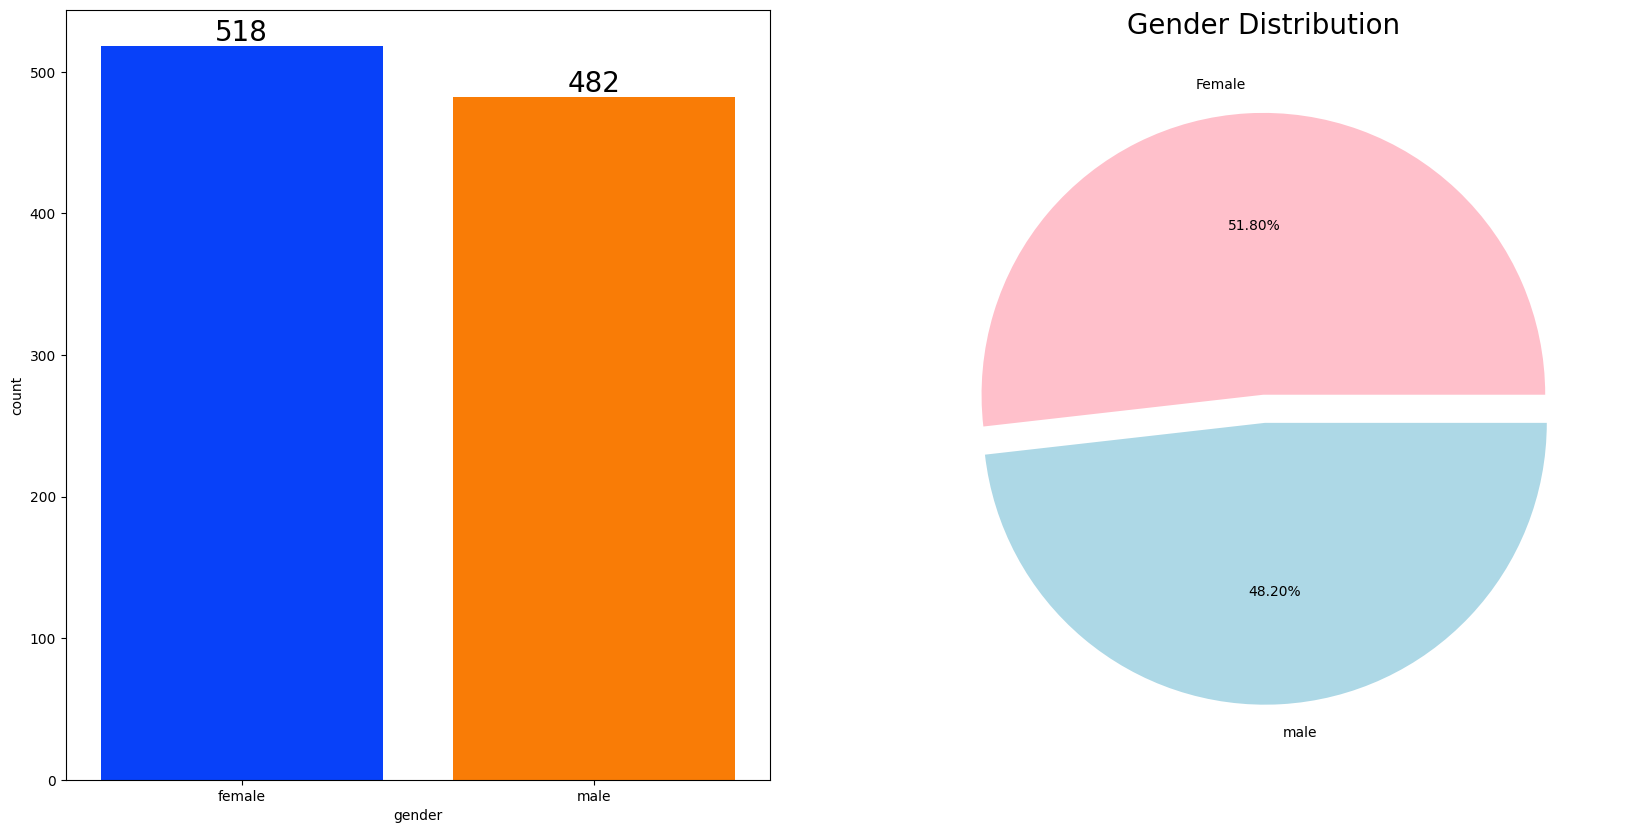

In [55]:
f, ax= plt.subplots(1, 2, figsize=(20, 10))
sns.countplot(x=df['gender'],data=df,palette ='bright',ax=ax[0],saturation=0.95)
for container in ax[0].containers:
    ax[0].bar_label(container,color='black',size=20) 

plt.pie(x=df['gender'].value_counts(), labels=['Female','male'], explode=[0,0.1], colors=['pink','lightblue'], autopct='%.2f%%')
plt.title('Gender Distribution', fontsize=20)
plt.axis('off') 




# Insights

Gender has balanced data with male students 482(48.20%) and female 510(52%) in number.





Bivariate analysis: Does gender have any impact on performace of the students?


In [56]:
#convert cetagorical to numerical(binary)
import pandas as pd
df_dummies = pd.get_dummies(df, columns=['gender'], drop_first=True)
df_dummies.head()


,race/ethnicity,parental level of education,lunch,test preparation course,math score,reading score,writing score,total_score,average_score,gender_male
0,group B,bachelor's degree,standard,none,72,72,74,218,72.666667,False
1,group C,some college,standard,completed,69,90,88,247,82.333333,False
2,group B,master's degree,standard,none,90,95,93,278,92.666667,False
3,group A,associate's degree,free/reduced,none,47,57,44,148,49.333333,True
4,group C,some college,standard,none,76,78,75,229,76.333333,True


In [57]:
# as the gender_group is in boolean form we need to change it in int form

df_dummies["gender_male"] = df_dummies["gender_male"].astype(int)
df_dummies.head()


,race/ethnicity,parental level of education,lunch,test preparation course,math score,reading score,writing score,total_score,average_score,gender_male
0,group B,bachelor's degree,standard,none,72,72,74,218,72.666667,0
1,group C,some college,standard,completed,69,90,88,247,82.333333,0
2,group B,master's degree,standard,none,90,95,93,278,92.666667,0
3,group A,associate's degree,free/reduced,none,47,57,44,148,49.333333,1
4,group C,some college,standard,none,76,78,75,229,76.333333,1


In [58]:
# grouping by gender and calculating the mean average score
gender_group = df_dummies.groupby('gender_male')['average_score'].mean()
gender_group # mean average score
 

gender_male
0    69.569498
1    65.837483
Name: average_score, dtype: float64

In [59]:
# grouping by gender and calculating the mean of their math scores 
math_group = df_dummies.groupby('gender_male')['math score'].mean()
math_group   # mean math score 

gender_male
0    63.633205
1    68.728216
Name: math score, dtype: float64

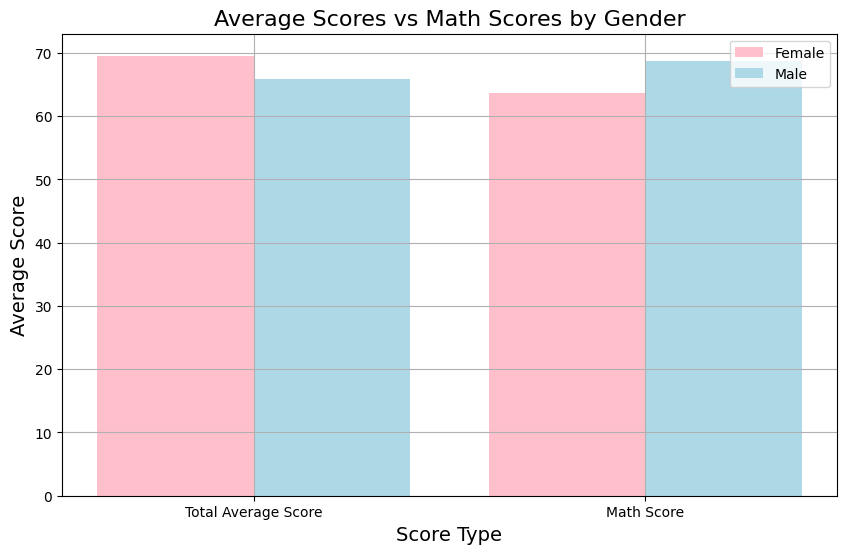

In [60]:
# now we have gender (in numerical form ) group by mean and math score also grouped by mean so we can compare between them in a bar plot(bivariate analysis)

plt.figure(figsize=(10, 6))
x = ["Total Average Score", "Math Score"]


female_scores = [gender_group.loc[0], math_group.loc[0]]
male_scores = [gender_group.loc[1], math_group.loc[1]]



x_axis = np.arange(len(x))


plt.bar(x_axis - 0.2, female_scores, width=0.4, label='Female', color='pink')
plt.bar(x_axis + 0.2, male_scores, width=0.4, label='Male', color='lightblue')
plt.xticks(x_axis, x)   
plt.xlabel('Score Type', fontsize=14)
plt.ylabel('Average Score', fontsize=14)
plt.title('Average Scores vs Math Scores by Gender', fontsize=16)
plt.legend()
plt.grid()

Insights
- on average female have better score than male 
- while male scored higher in maths than females

# 4.4.2 Race/Ethnicity 
Univariate Analysis
- How is (race/ethnicity) group wise distribution?



(-1.25, 1.25, -1.25, 1.25)

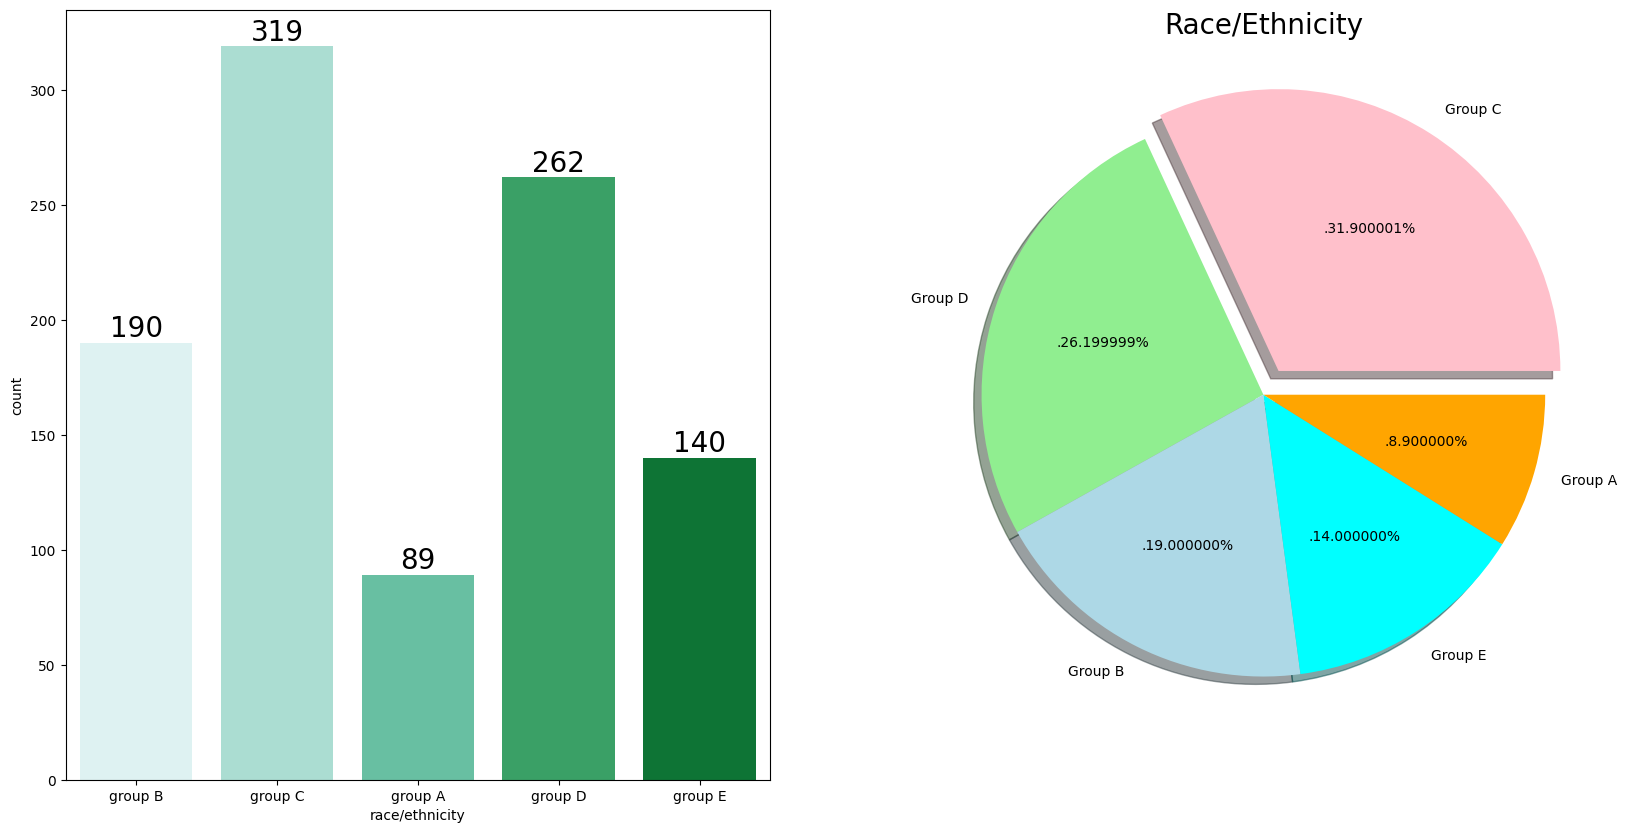

In [61]:
f,ax=plt.subplots(1,2,figsize=(20,10)) 

sns.countplot(x=df['race/ethnicity'],data=df,palette ='BuGn',ax = ax[0],saturation=0.95)
for container in ax[0].containers:
    ax[0].bar_label(container,color='black',size=20)
size = df['race/ethnicity'].value_counts()
labels = 'Group C', 'Group D','Group B','Group E','Group A'
color = ['pink', 'lightgreen', 'lightblue', 'cyan','orange']
ax[1].pie(size, colors = color,labels = labels,autopct = '.%2f%%', shadow = True, explode=[0.1,0,0,0,0])
ax[1].set_title('Race/Ethnicity', fontsize = 20)
ax[1].axis('off')







# Insights
- Most of the students belong to group C with 319 in number 
- Least amount of students belong to group A (only 89)


# Bivariate Analysis

- Does Race/Ethnicity of the students have any impact on their academic performance ?

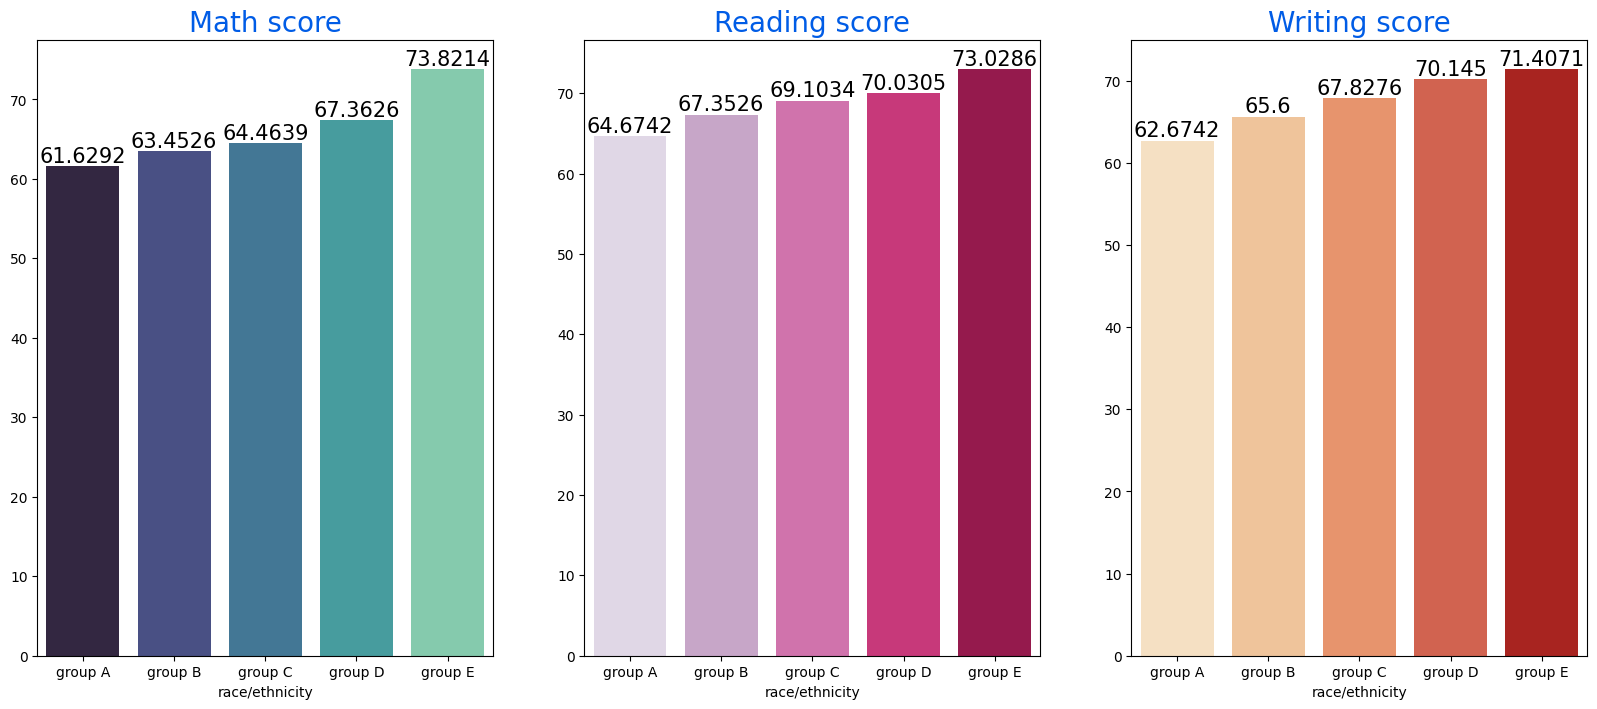

In [62]:
group_race = df.groupby('race/ethnicity')
f, ax = plt.subplots(1, 3, figsize=(20, 8))


sns.barplot(x=group_race['math score'].mean().index, y=group_race['math score'].mean().values, palette = 'mako', ax=ax[0])
ax[0].set_title('Math score',color='#005ce6',size=20)
for container in ax[0].containers:
    ax[0].bar_label(container,color='black',size=15)


sns.barplot(x=group_race['reading score'].mean().index, y=group_race['reading score'].mean().values, palette = 'PuRd', ax=ax[1])
ax[1].set_title('Reading score',color='#005ce6',size=20)
for container in ax[1].containers:
    ax[1].bar_label(container,color='black',size=15)


sns.barplot(x=group_race['writing score'].mean().index, y=group_race['writing score'].mean().values, palette = 'OrRd', ax=ax[2])
ax[2].set_title('Writing score',color='#005ce6',size=20)
for container in ax[2].containers:
    ax[2].bar_label(container,color='black',size=15)

    

# Insights 
- Group E students got the highest marks in all the subjects
- Grop A studets scored lowest in all 3 subjects



# 4.4.3 Parental level of Education
Univariate Analysis
- How does its distribution look like?

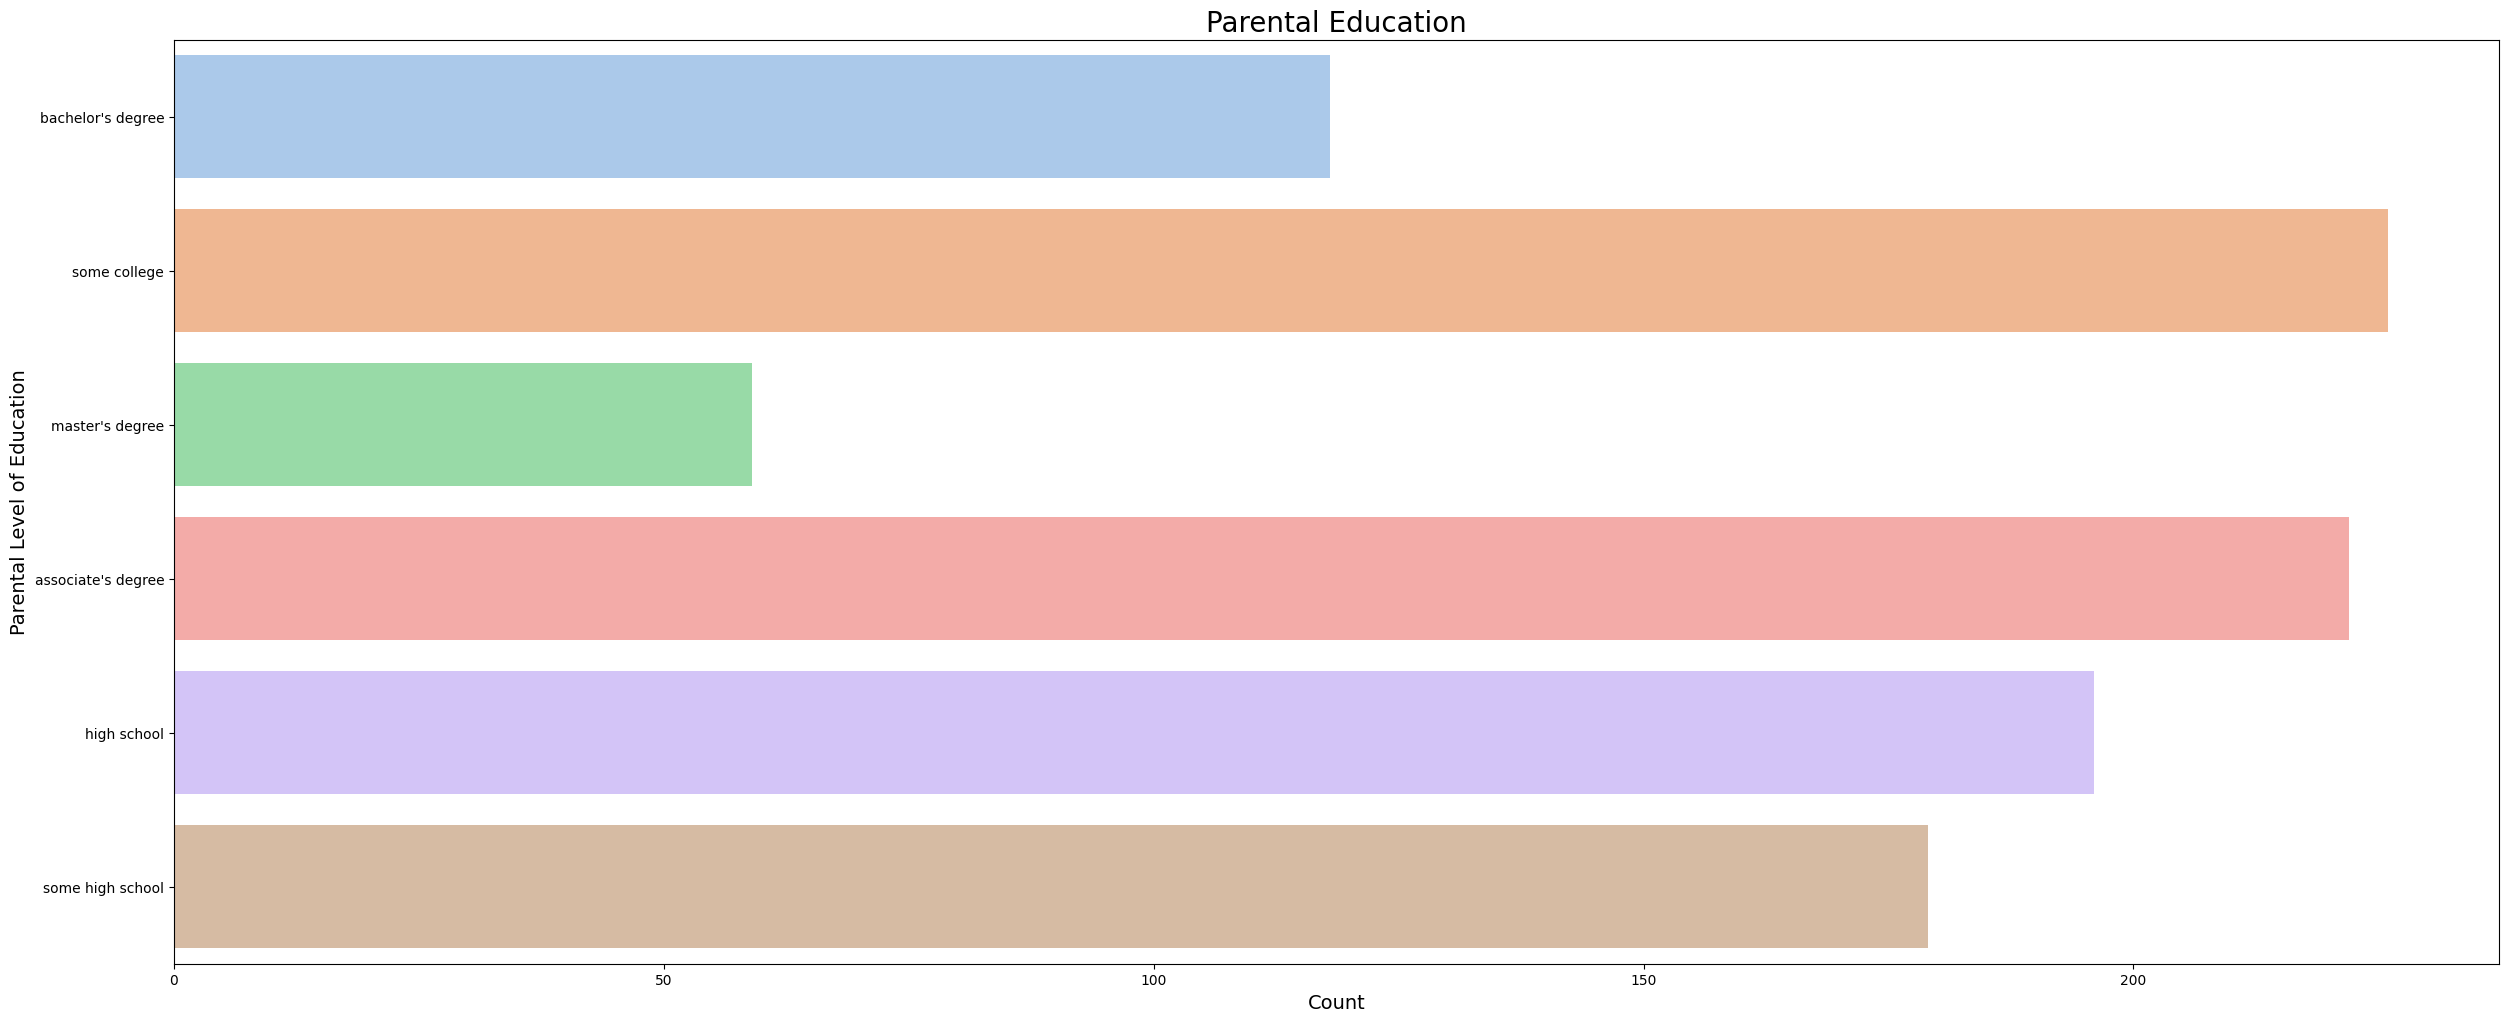

In [63]:
plt.plot(figsize=(10, 6))
sns.countplot(df['parental level of education'], palette= "pastel")
plt.ylabel('Parental Level of Education', fontsize = 14)
plt.xlabel('Count', fontsize = 14)
plt.title('Parental Education', fontsize = 20)
plt.show()




# Insights 
- Most of the students' parents hold some college or associate degree
- only a small percentage of parents hold a masters degree




# Bivariate Analysis
- Does Parental level of education impacts the academic performance of students?

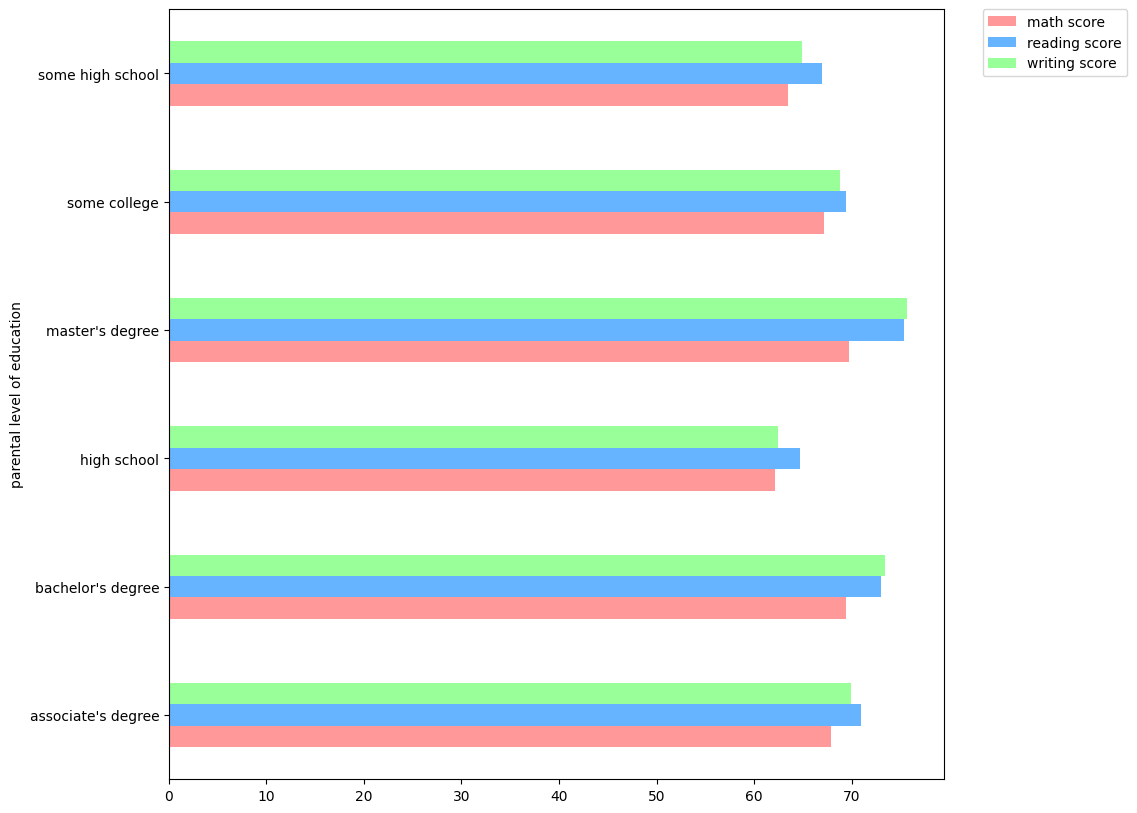

In [64]:
grouped = df.groupby('parental level of education')[['math score', 'reading score', 'writing score']].mean()
grouped.plot(kind='barh', figsize=(10, 10), color=['#ff9999','#66b3ff','#99ff99'])
plt.legend(bbox_to_anchor=(1.05, 1), loc=2, borderaxespad=0.)
plt.show()

# Insights 
- students whose parents possess a masters and bachelors scored the highest marks overall and performed better than others.
- those who have highschool level education , their kids performed worse than others in academics

# 4.4.4 Lunch Column

Univaraiate Analysis
- How does the distrubtion look  like?

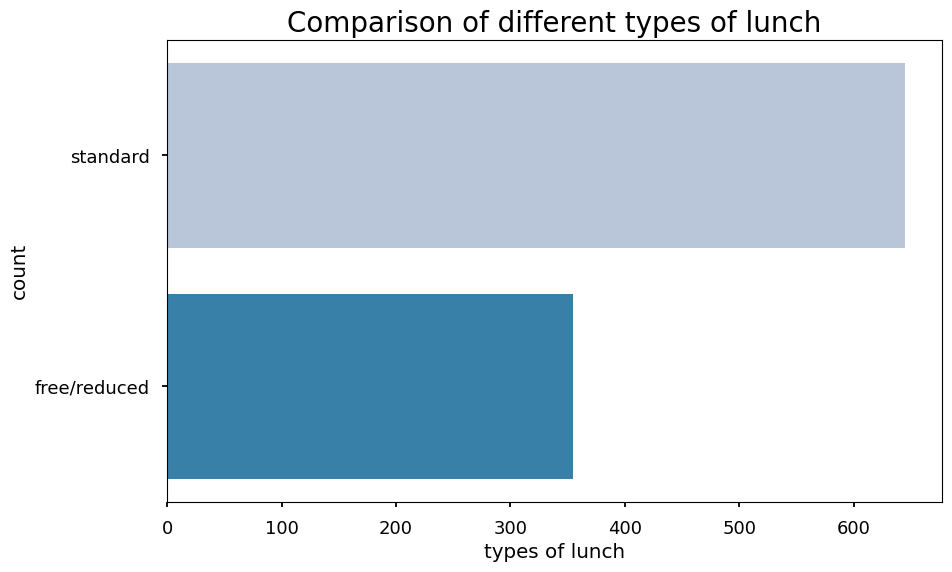

In [72]:
plt.figure(figsize=(10, 6))
plt.rcParams['figure.figsize'] = (15, 9)
sns.countplot(df['lunch'], palette = 'PuBu')
plt.title('Comparison of different types of lunch', fontweight = 30, fontsize = 20)
plt.xlabel('types of lunch')
plt.ylabel('count')
plt.show()

# Insights 
- From above univariate analysis of students (male or female) taking lunch suggests that 65 % of them get standard lunch
- whereas 36% of students get free or no lunch
- students who get standard lunch are more than who do not.




# Bivariate Analysis
-  Does lunch type have any impact on students academic performance ?


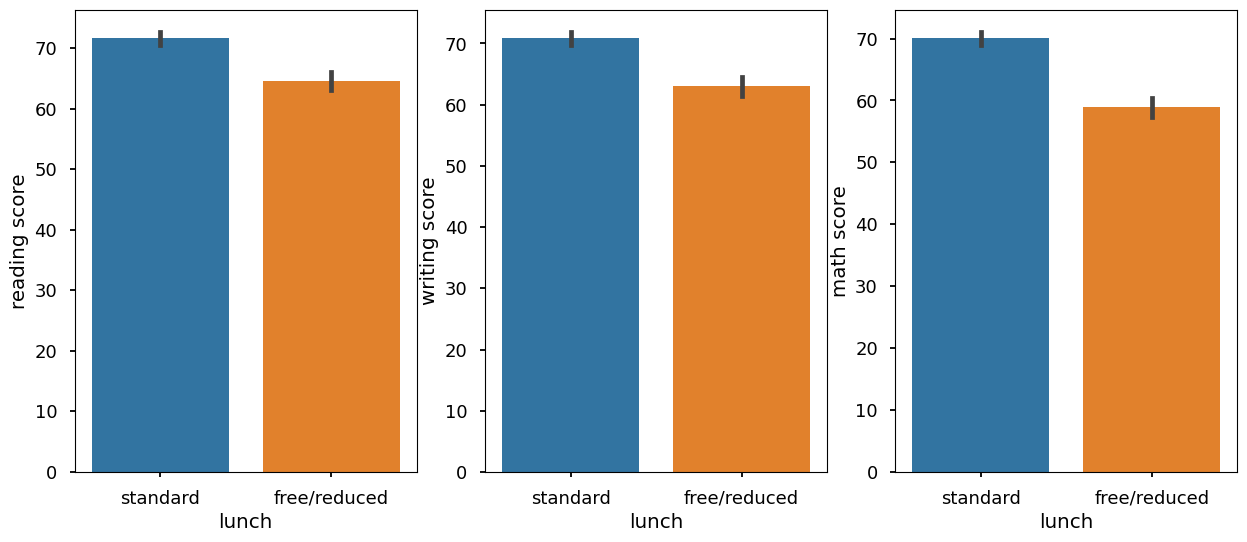

In [80]:
plt.figure(figsize=(15,6))
plt.subplot(1, 3, 1)
sns.barplot(x=df['lunch'],y=df['reading score'], hue=df['lunch'])
plt.subplot(1, 3, 2)    
sns.barplot(x=df['lunch'],y=df['writing score'], hue=df['lunch'])
plt.subplot(1, 3, 3)    
sns.barplot(x=df['lunch'],y=df['math score'], hue=df['lunch'])
plt.show()



# Insights:
- Students who get standard lunch performed better in all three subjects than those who get free/reduced lunch 





# 4.4.5 Test preparation course Analysis

# Univariate Analysis
-  How does the distribution look like?


Text(0.5, 1.0, 'Test Preparation Course')

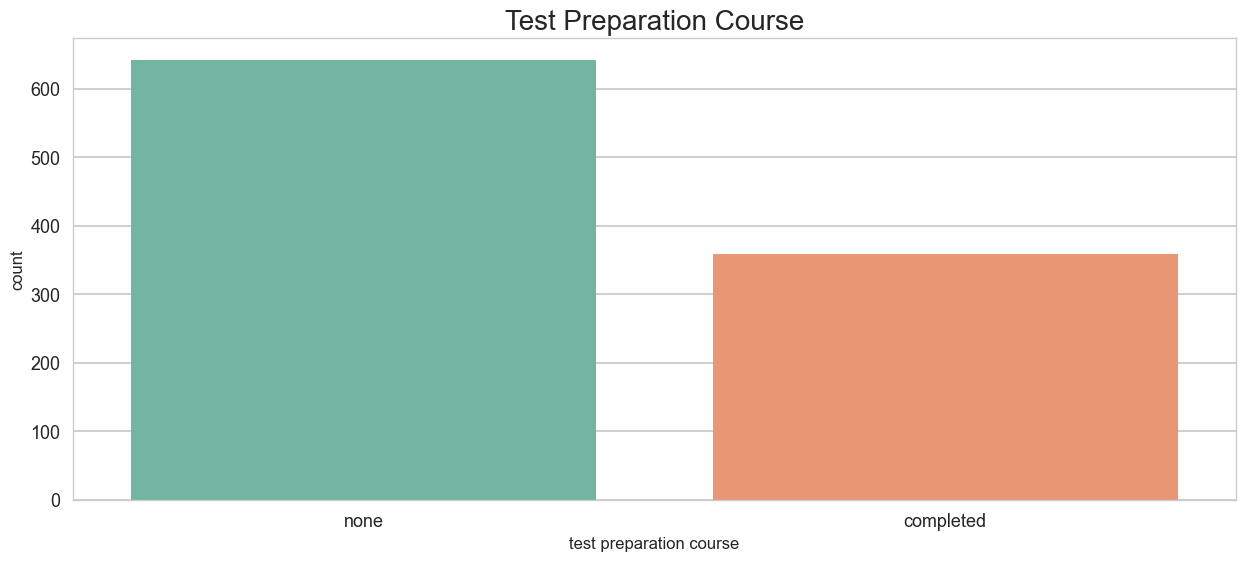

In [86]:
plt.rcParams['figure.figsize'] = (15, 6)
plt.style.use('seaborn-whitegrid')
labels = 'None', 'Completed'
sns.countplot(x=df['test preparation course'], palette='Set2')
plt.title('Test Preparation Course', fontsize=20)

# Insights
- Students who took test preparation course are more than those wo did not




# Bivariate Analysis
- Does taking test preparation course have any impact on students' academic performance?

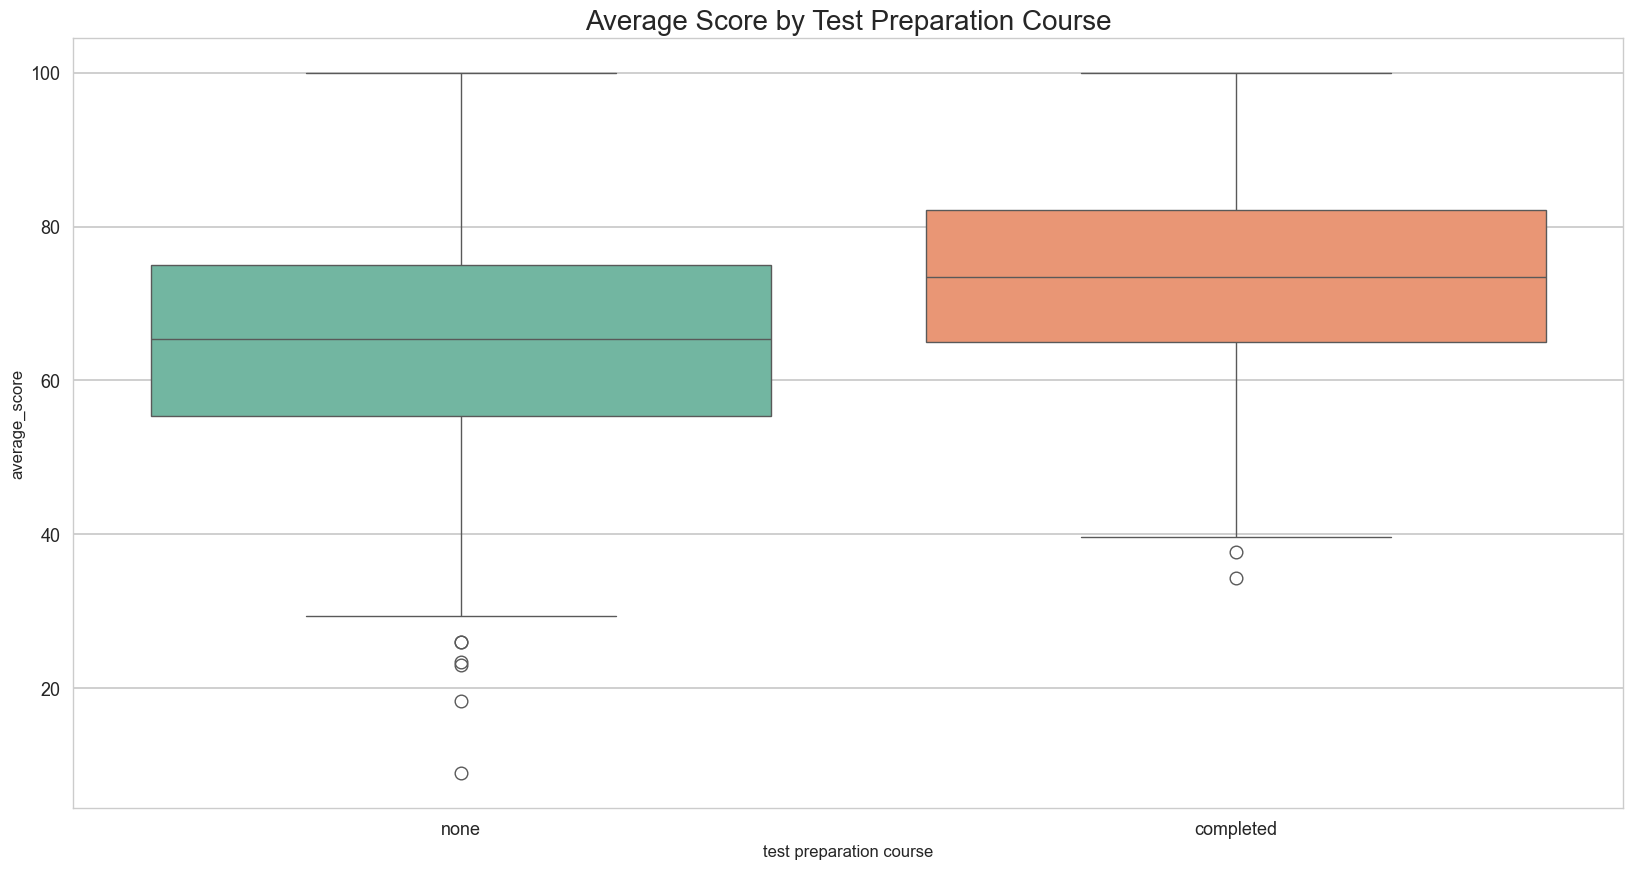

In [ ]:
# to show the distribution of average score based on test preparation course
plt.figure(figsize=(20, 10))
sns.boxplot(x=df['test preparation course'],y=df['average_score'], palette='Set2')
plt.title('Average Score by Test Preparation Course', fontsize=20)  
plt.show()

# Insights

- From above box plot we can analyze that those students who completed test preparartion course have a better average score than those did not take one


<Axes: xlabel='test preparation course', ylabel='writing score'>

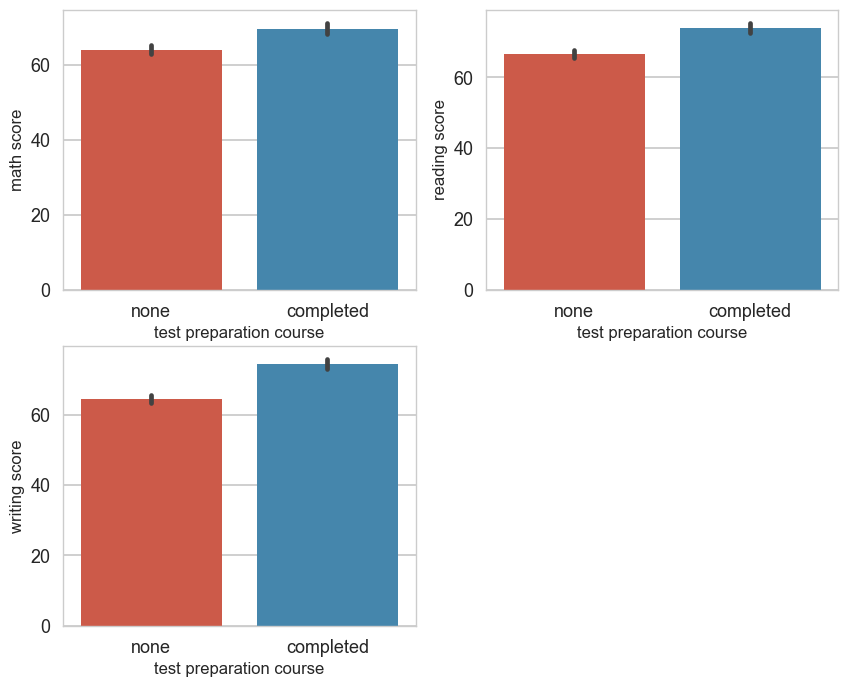

In [ ]:
# to show the distribution of the individual score of each subject based on test preparation course
plt.figure(figsize=(10,8))
plt.subplot(2,2,1)
sns.barplot (x=df['test preparation course'], y=df['math score'], hue=df['test preparation course'])
plt.subplot(2,2,2)
sns.barplot (x=df['test preparation course'], y=df['reading score'], hue=df['test preparation course'])
plt.subplot(2,2,3)
sns.barplot (x=df['test preparation course'], y=df['writing score'], hue=df['test preparation course'])

# Insights
- From above charts we can see that those who complteted test preparation course performed better in each subject than those who did not.


# Checking Outliers



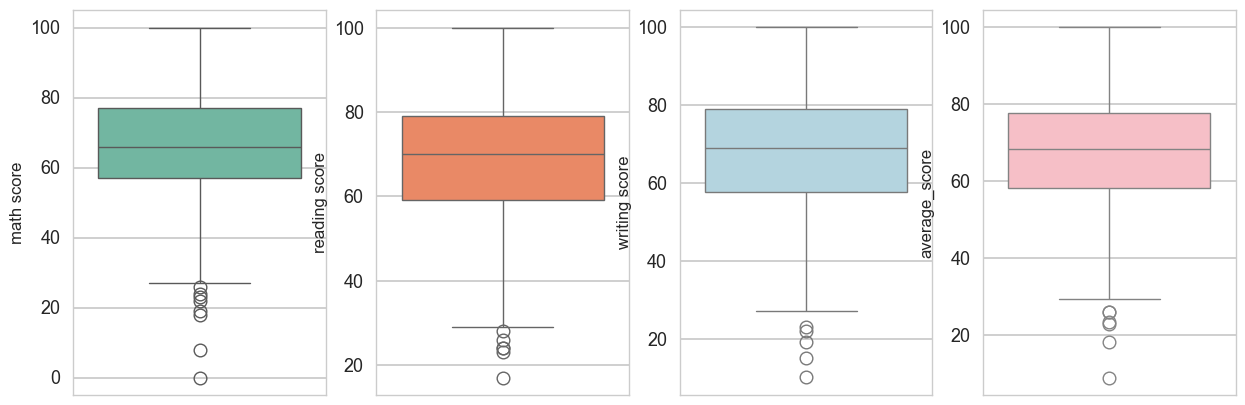

In [102]:
plt.subplots(1, 4, figsize=(15, 5))
plt.subplot(1, 4, 1)
sns.boxplot(df['math score'], palette='Set2')
plt.subplot(1, 4, 2)
sns.boxplot(df['reading score'], color='coral')
plt.subplot(1, 4, 3)
sns.boxplot(df['writing score'], color='lightblue')
plt.subplot(1, 4, 4)
sns.boxplot(df['average_score'], color='lightpink')
plt.show()

# Insights
- From above box plots, we can suggest that there are few exceptional outliers, students who performed worse compared average scores
- similarly, ther are some exceptional outperformers as well(high performing students)





# Multivariate Analysis using Pairplot

<Figure size 1000x600 with 0 Axes>

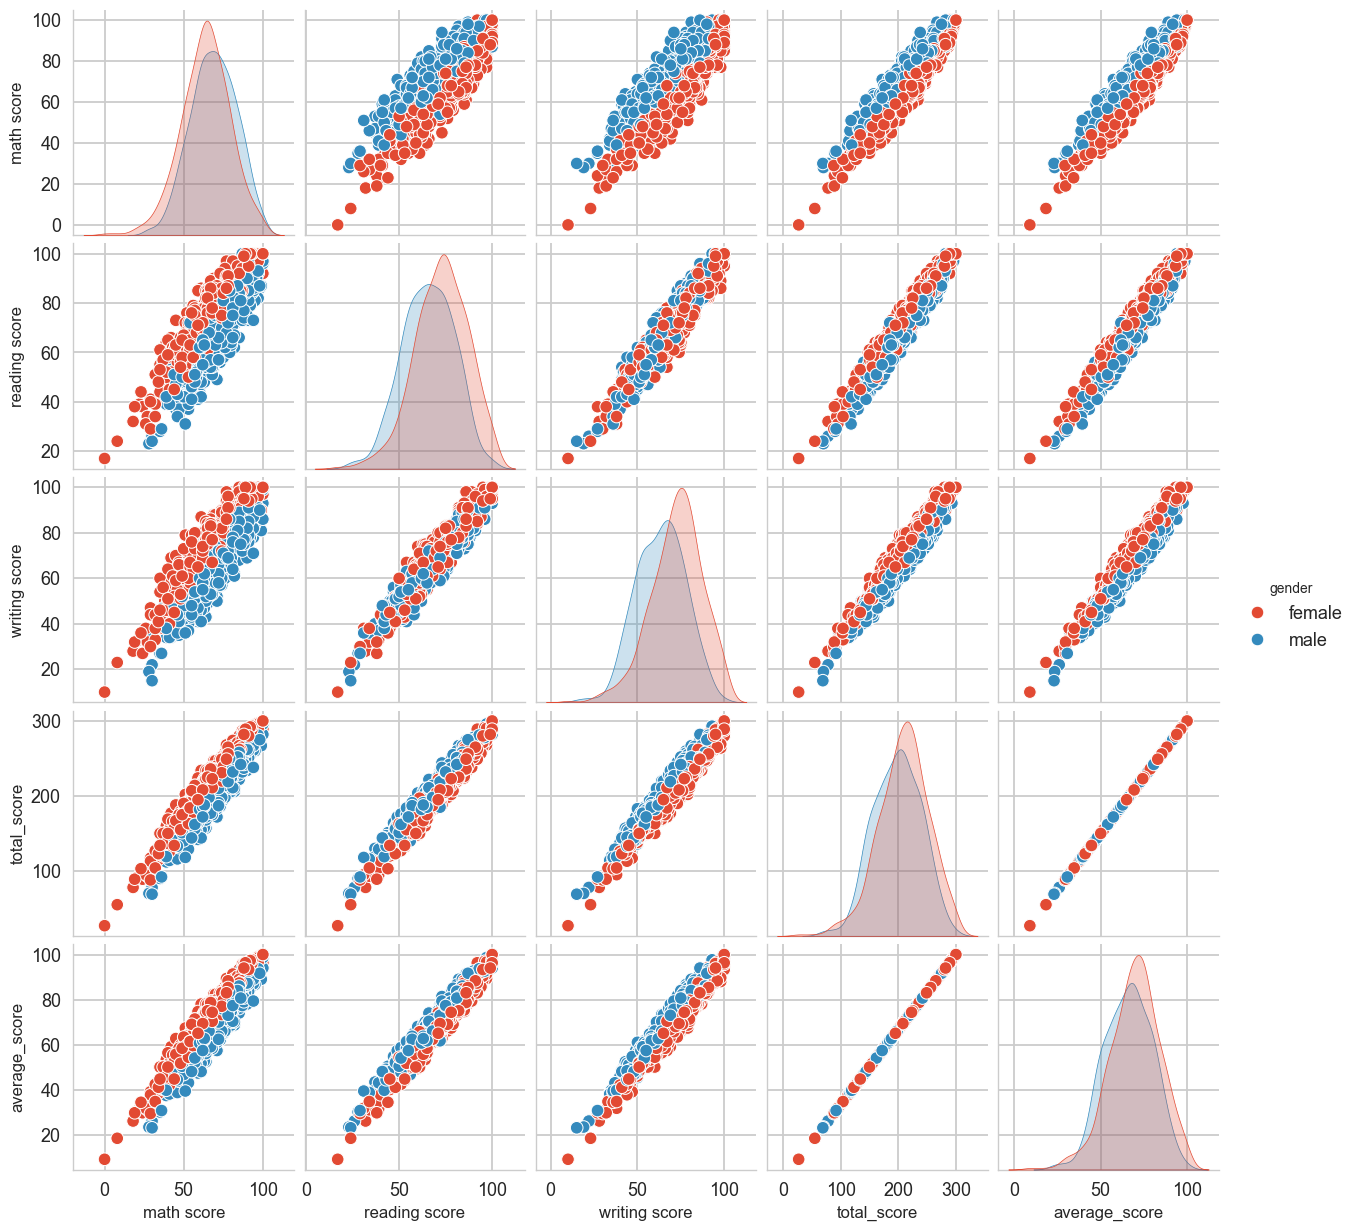

In [108]:
plt.figure(figsize=(10,6))
sns.pairplot(df, hue= 'gender')

- From above multivariate analysis, it is clear that alla the scores have a linear relationship wiht each other




# Conclusions
- Female students outperofrmed the male students in overall acedemic performance
- Students performance is related with the race/ethnicity, parental education level, lunch type, test preparation course.
